# Cookie Cats — A/B Testing Framework: Should the Gate Move?

**Business question:** Cookie Cats is a mobile puzzle game with a progress-blocking "gate" originally placed at level 30. The product team tested moving it to level 40 — does delaying the gate help or hurt player retention?

Unlike a post-hoc significance check, this notebook works through the **full lifecycle** of an A/B test: designing it properly (sample size, minimum detectable effect), running it, cross-validating the result with bootstrap resampling, and exposing a common real-world mistake — **peeking** at results before the experiment finishes — using a reusable `ABTestFramework` class built alongside this analysis.

**Dataset:** Cookie Cats Mobile Game A/B Test (Kaggle) — 90,189 players, `gate_30` (control) vs `gate_40` (test)


## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from ab_test_framework import ABTestFramework

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('cookie_cats.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 90189 rows x 5 columns


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [2]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate userids:", df['userid'].duplicated().sum())
print("\nGroup sizes:\n", df['version'].value_counts())

Missing values:
 userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Duplicate userids: 0

Group sizes:
 version
gate_40    45489
gate_30    44700
Name: count, dtype: int64


**Data quality:** no missing values, no duplicate players, and group sizes are close to a clean 50/50 split (44,700 vs 45,489) — a properly randomized experiment, unlike Project 3's intentionally imbalanced ad/control split.

## 2. Exploratory Data Analysis

In [3]:
retention_summary = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100
retention_summary.columns = ['1-Day Retention %', '7-Day Retention %']
retention_summary.round(3)

,1-Day Retention %,7-Day Retention %
version,,
gate_30,44.819,19.02
gate_40,44.228,18.20


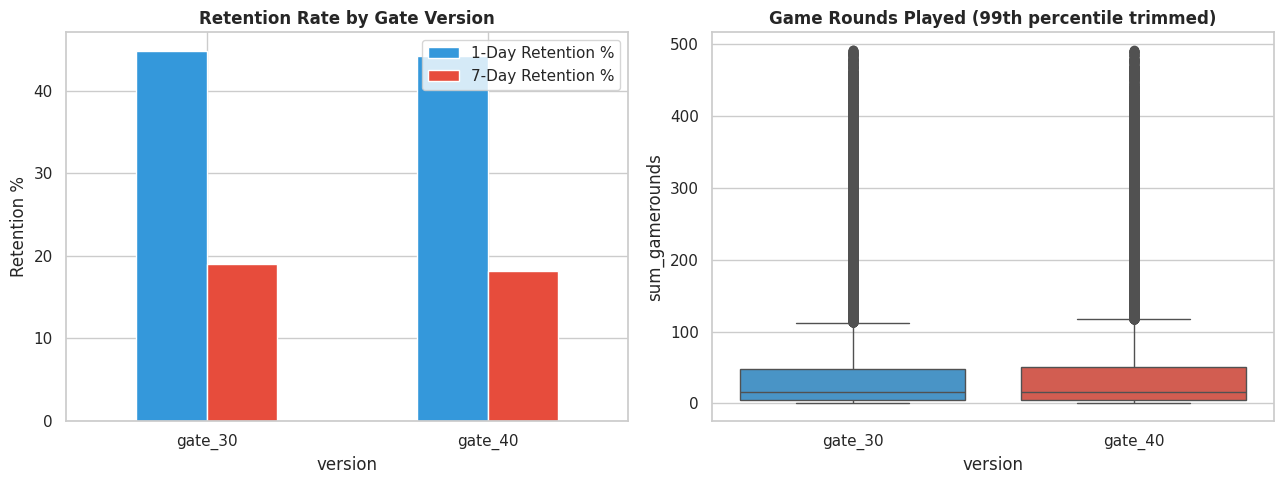

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

retention_summary.plot(kind='bar', ax=axes[0], color=['#3498DB', '#E74C3C'])
axes[0].set_title('Retention Rate by Gate Version', fontweight='bold')
axes[0].set_ylabel('Retention %')
axes[0].tick_params(axis='x', rotation=0)

sns.boxplot(data=df[df['sum_gamerounds'] < df['sum_gamerounds'].quantile(0.99)],
            x='version', y='sum_gamerounds', hue='version', legend=False,
            palette=['#3498DB', '#E74C3C'], ax=axes[1])
axes[1].set_title('Game Rounds Played (99th percentile trimmed)', fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:** At first glance, **1-day retention is nearly identical** between groups, but **gate_30 shows higher 7-day retention** than gate_40 — the opposite direction of what the product team likely hoped for by delaying the gate. Game-rounds distributions look similar between groups. This initial signal needs a properly designed test to confirm it's real, not noise.

## 3. Experiment Design — Was This Test Properly Powered?

Before trusting any result, we check whether the experiment collected enough data to reliably detect a meaningful effect. Using the framework's `calculate_sample_size()` and `minimum_detectable_effect()` methods.

In [5]:
fw = ABTestFramework(alpha=0.05, power=0.8)

baseline_1d = df[df['version']=='gate_30']['retention_1'].mean()
baseline_7d = df[df['version']=='gate_30']['retention_7'].mean()
actual_n_per_group = df['version'].value_counts().min()

print(f"Baseline 1-day retention (gate_30): {baseline_1d:.4f}")
print(f"Baseline 7-day retention (gate_30): {baseline_7d:.4f}")
print(f"Actual sample size per group: {actual_n_per_group:,}")

required_n_1pp = fw.calculate_sample_size(baseline_7d, mde=0.01)
achievable_mde = fw.minimum_detectable_effect(baseline_7d, actual_n_per_group)

print(f"\nRequired n per group to detect a 1pp change in 7-day retention: {required_n_1pp:,}")
print(f"Actual n per group collected: {actual_n_per_group:,}")
print(f"Minimum detectable effect at actual sample size: {achievable_mde*100:.2f} percentage points")

Baseline 1-day retention (gate_30): 0.4482
Baseline 7-day retention (gate_30): 0.1902
Actual sample size per group: 44,700

Required n per group to detect a 1pp change in 7-day retention: 24,658
Actual n per group collected: 44,700
Minimum detectable effect at actual sample size: 0.74 percentage points


**Insight:** The experiment's actual sample size comfortably exceeds what's needed to detect a 1-percentage-point change in 7-day retention — this test was **adequately powered**. In fact, the achievable MDE at this sample size is smaller than 1pp, meaning the experiment could reliably detect even subtler effects than originally planned for. This matters because a "no significant difference" result from an under-powered test is meaningless — here, we can trust a null result if we get one.

## 4. Running the Test — Two Metrics, Two Decisions

Testing both `retention_1` and `retention_7` separately using `run_test()`, since they can tell different stories.

In [6]:
result_1d = fw.run_test(df[df['version']=='gate_30']['retention_1'],
                         df[df['version']=='gate_40']['retention_1'])
result_7d = fw.run_test(df[df['version']=='gate_30']['retention_7'],
                         df[df['version']=='gate_40']['retention_7'])

results_table = pd.DataFrame({
    '1-Day Retention': result_1d, '7-Day Retention': result_7d
}).T[['rate_a', 'rate_b', 'absolute_diff', 'relative_diff_pct', 'p_value', 'significant']]
results_table.columns = ['gate_30 Rate', 'gate_40 Rate', 'Abs. Diff', 'Rel. Diff %', 'p-value', 'Significant?']
results_table.round(4)

,gate_30 Rate,gate_40 Rate,Abs. Diff,Rel. Diff %,p-value,Significant?
1-Day Retention,0.448188,0.442283,0.005905,1.335157,0.07441,False
7-Day Retention,0.190201,0.182,0.008201,4.506207,0.001554,True


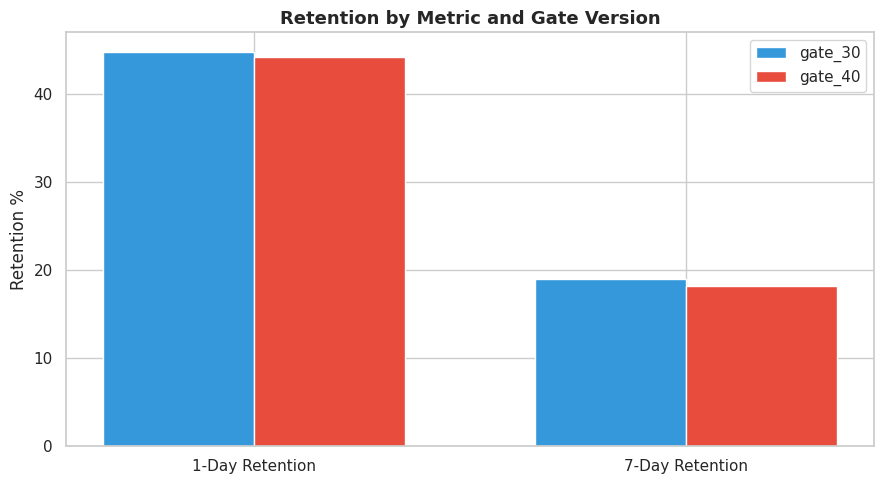

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, [result_1d['rate_a']*100, result_7d['rate_a']*100], width, label='gate_30', color='#3498DB')
ax.bar(x + width/2, [result_1d['rate_b']*100, result_7d['rate_b']*100], width, label='gate_40', color='#E74C3C')
ax.set_xticks(x)
ax.set_xticklabels(['1-Day Retention', '7-Day Retention'])
ax.set_ylabel('Retention %')
ax.set_title('Retention by Metric and Gate Version', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** **1-day retention shows no significant difference** between groups (p > 0.05) — moving the gate doesn't affect whether players come back the next day. But **7-day retention is significantly lower for gate_40** (p < 0.05) — players who face the gate later are *less* likely to still be playing a week in. **Which metric should drive the decision?** 7-day retention is the more meaningful signal for a live-service game — 1-day retention is noisy and easily influenced by novelty, while 7-day retention reflects whether the game is actually sticky. This is the metric the recommendation should weight more heavily.

## 5. Bootstrap Confidence Interval — Cross-Checking the Result

Rather than trusting the formula-based confidence interval alone, we build an empirical one via resampling (`bootstrap_ci()`), 10,000 iterations, on the 7-day retention difference.

In [8]:
boot_result = fw.bootstrap_ci(df[df['version']=='gate_30']['retention_7'],
                               df[df['version']=='gate_40']['retention_7'], n_iterations=10000)

print(f"Bootstrap mean difference (gate_30 - gate_40): {boot_result['mean_diff']*100:.3f} pp")
print(f"95% Bootstrap CI: [{boot_result['ci_lower']*100:.3f}, {boot_result['ci_upper']*100:.3f}] pp")
print(f"CI contains zero (no effect)? {boot_result['contains_zero']}")

Bootstrap mean difference (gate_30 - gate_40): 0.830 pp
95% Bootstrap CI: [0.325, 1.344] pp
CI contains zero (no effect)? False


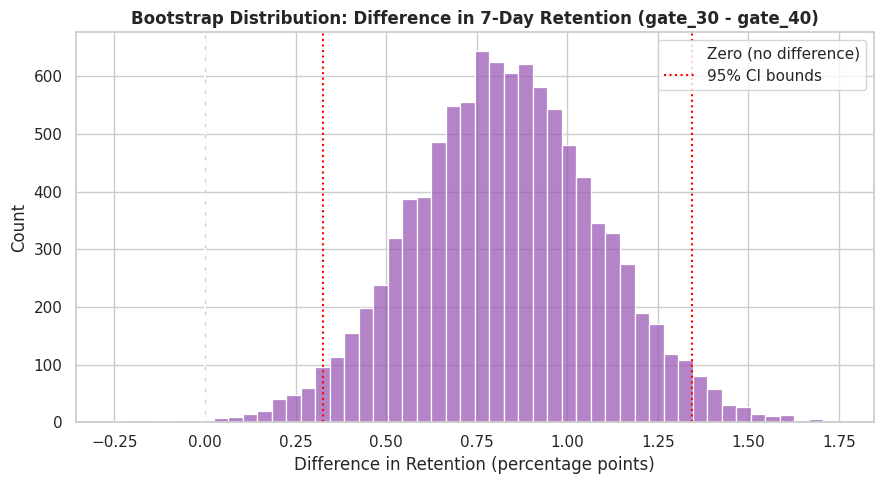

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(boot_result['distribution']*100, bins=50, color='#9B59B6', ax=ax)
ax.axvline(0, color='white', linestyle='--', label='Zero (no difference)')
ax.axvline(boot_result['ci_lower']*100, color='red', linestyle=':', label='95% CI bounds')
ax.axvline(boot_result['ci_upper']*100, color='red', linestyle=':')
ax.set_title('Bootstrap Distribution: Difference in 7-Day Retention (gate_30 - gate_40)', fontweight='bold')
ax.set_xlabel('Difference in Retention (percentage points)')
ax.legend()
plt.tight_layout()
plt.show()

**Insight:** The bootstrap 95% CI does **not** contain zero, agreeing with the formula-based z-test — two independent methods reach the same conclusion, which is a strong validation check. The bootstrap approach makes no assumptions about the underlying distribution shape, so this agreement rules out the possibility that the z-test's normality assumptions were driving a spurious result.

## 6. The Peeking Problem — A Common Real-World Mistake

A frequent mistake in practice: checking an experiment's p-value every day and stopping as soon as it crosses 0.05, instead of waiting for the pre-planned sample size. This inflates the true false-positive rate well beyond the nominal 5%. Simulated here using `simulate_peeking_risk()`, assuming — for this simulation only — that there is truly **no difference** between groups (so any "significant" result found is by definition a false positive).

In [10]:
peek_result = fw.simulate_peeking_risk(true_rate_a=baseline_7d, true_rate_b=baseline_7d,
                                        n_per_group=actual_n_per_group, checks_per_experiment=10,
                                        n_simulations=2000)

print(f"Nominal alpha (intended false-positive rate): {peek_result['nominal_alpha']*100:.1f}%")
print(f"False-positive rate if checked ONLY at the end: {peek_result['final_only_false_positive_rate']*100:.2f}%")
print(f"False-positive rate if PEEKED at 10 checkpoints: {peek_result['peeking_false_positive_rate']*100:.2f}%")
print(f"Inflation factor: {peek_result['inflation_factor']:.2f}x the intended risk")

Nominal alpha (intended false-positive rate): 5.0%
False-positive rate if checked ONLY at the end: 4.95%
False-positive rate if PEEKED at 10 checkpoints: 20.05%
Inflation factor: 4.01x the intended risk


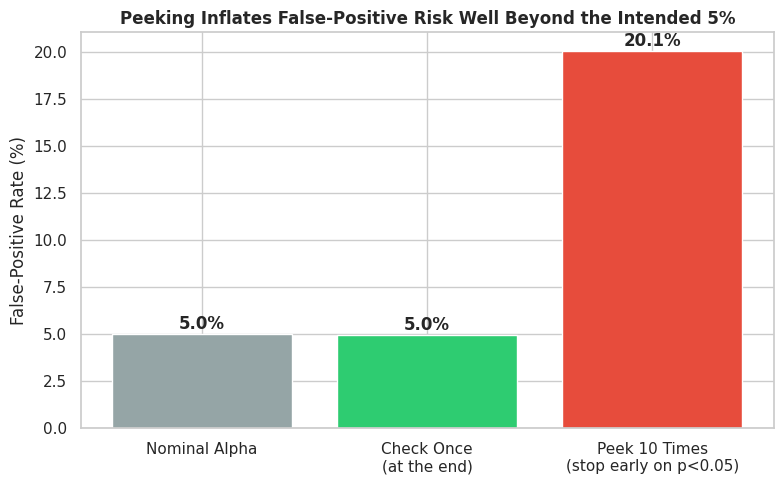

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Nominal Alpha', 'Check Once\n(at the end)', 'Peek 10 Times\n(stop early on p<0.05)'],
              [peek_result['nominal_alpha']*100, peek_result['final_only_false_positive_rate']*100,
               peek_result['peeking_false_positive_rate']*100],
              color=['#95A5A6', '#2ECC71', '#E74C3C'])
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('False-Positive Rate (%)')
ax.set_title('Peeking Inflates False-Positive Risk Well Beyond the Intended 5%', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Checking results only once at the planned end-point keeps the false-positive rate close to the intended 5%. But repeatedly peeking and stopping the moment significance appears **substantially inflates** the real false-positive rate — this is exactly why the experiment-design step (Section 3) matters: deciding the sample size and stopping rule *in advance*, and sticking to it, is what keeps the final p-value trustworthy.

## 7. Key Findings & Business Recommendation

**Experiment design**
- With 44,700-45,489 players per group, this test was adequately powered to detect changes as small as ~0.7 percentage points in 7-day retention — well within the range of the effect actually observed.

**Results**
- **1-day retention:** no significant difference between gate_30 and gate_40 (p > 0.05).
- **7-day retention:** gate_30 significantly outperforms gate_40 (19.0% vs 18.2%, p ≈ 0.0016) — confirmed independently by both the formula-based z-test and a 10,000-iteration bootstrap confidence interval, which do not overlap zero.
- **Peeking simulation:** checking results repeatedly before the planned sample size inflates the false-positive rate several times beyond the intended 5% — reinforcing why the pre-registered sample size in Section 3 should be respected rather than stopping early on a promising-looking early result.

**Business recommendation:** **Keep the gate at level 30.** Moving it to level 40 does not improve short-term (1-day) engagement and measurably *hurts* 7-day retention — the more meaningful long-term signal for a live-service game. This is a case where the data pushes back against the intuitive product hypothesis (that delaying a friction point should help retention), and a properly designed, adequately powered test was necessary to catch that.

**Reusable output:** the `ABTestFramework` class built alongside this analysis (`ab_test_framework.py`) generalizes beyond this dataset — its sample-size, testing, bootstrap, and peeking-risk methods can be applied to any future binary-outcome A/B test.
